# Confidence calibration — eagle3 / suffix / draft_model / mtp (EAGLE-2 Fig.6 reproduction)

Reads `simulation/results/explorations/calib_<wl>_s8k8_chain_replay.json` produced by `compute_confidence_calibration.py`.

**Trial / accept (EAGLE-2 strict):** for each draft node n at depth d, n is a *trial* iff its parent path matches `gt[0:d-1]` (parent would be accepted in tree verification) AND `len(gt) >= d`. Accept iff also `token[n] == gt[d-1]`. Per-bin accept rate = `accepts[bin] / trials[bin]`.

**Three confidence axes per method:**
* **per_step** — per-NODE single-step transition prob, recovered as `cum[i] / cum[parent[i]]`. Range [0, 1]. Direct EAGLE-2 Fig.6 analog. Diagonal `y = x` is the perfect-calibration reference.
* **path_prob** — per-NODE cumulative path-product (= `path_draft_p_t[i]` for eagle3/draft_model/mtp, `probs[i]` for suffix). Range [0, 1]. The metric tree pruning actually uses.
* **score** — per-DRAFT scalar `SuffixDraft.score = sum(probs)` (suffix) / `sum(path_draft_p_t)` (others), used **raw** (no normalization). Range `[0, score_max]`. Per-DEPTH-GROUP trial unit (sibling group = 1 trial, ANY-match = accept).

**Source data per method:**
* eagle3 — Qwen3-14B EAGLE3 head, `path_draft_p_t` (per-node cumulative path-product of draft head softmax probs).
* suffix — `SuffixDraft.probs` / `SuffixDraft.score` from arctic_inference (`vendor/ArcticInference/csrc/suffix_decoding/suffix_tree.cc`).
* draft_model — Qwen3-0.6B drafting Qwen3-14B target via STANDALONE algo + replay-vanilla mode. **Chain config (topk=1, num_draft=9)** captured via `simulation/scripts/replay_capture.py` (bypasses agent loop; submits prompts directly via /v1/completions). `oracle_patch.py:patched_verify` overrides `res.verified_id` AND `res.draft_input.verified_id` BEFORE `forward_draft_extend_after_decode` runs, so next-step draft is correctly seeded with the trajectory token. Avg accept rate now in deploy-realistic 73-93% range vs prior tree-DM 0.8-1.8% (which had outer-level override timing bug).
* mtp — Qwen3.5-9B native MTP head (vanilla mode, no replay; mtp's own committed tokens used as gt). Not regenerated for chain_replay — falls back to legacy `_4method_v4` data when present.

Bin convention: 64 equal-width bins per axis, `score_max=64`.

Color: eagle3 blue, suffix orange, draft_model green, mtp purple.

In [ ]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path('/home/muchwater/advance-spec/simulation/results')
EXPL = ROOT / 'explorations'
WORKLOADS = ['bfcl_v4', 'specbench', 'swebench_verified']
RESLICE = 's8k8'
# tree_replay = TREE-mode (topk=16, num_draft=128) draft model captured via
# replay_capture.py (bypass-agent harness) + raw verified-token trajectory
# + verify-level override (patched_verify mirrors res.verified_id +
# res.draft_input.verified_id before forward_draft_extend_after_decode).
# This is the production-realistic draft tree shape. avg accept dilutes
# vs chain (per-node averaging over wrong-sibling nodes), but bin[63]
# (high-confidence) remains 96-99% — confirming the calibration shape.
# Prior tree DM (`qwen3_14b_dm/`) had 4 buggy pipeline issues that pushed
# avg to 0.8-1.8%; resolved by full chain → tree validation flow.
CALIB_SUFFIX = '_tree_replay'

EAGLE3_COLOR = '#1f77b4'   # tab:blue
SUFFIX_COLOR = '#ff7f0e'   # tab:orange
DM_COLOR = '#2ca02c'       # tab:green
MTP_COLOR = '#9467bd'      # tab:purple
COLORS = {'eagle3': EAGLE3_COLOR, 'suffix': SUFFIX_COLOR,
          'draft_model': DM_COLOR, 'mtp': MTP_COLOR}

def load_calib(wl):
    p = EXPL / f'calib_{wl}_{RESLICE}{CALIB_SUFFIX}.json'
    if not p.exists():
        # Fallback to legacy filename when v4 is absent.
        p = EXPL / f'calib_{wl}_{RESLICE}.json'
    if not p.exists():
        return None
    with open(p) as f:
        return json.load(f)

def per_bin_rate(entry):
    trials = np.asarray(entry['trials'], dtype=float)
    accepts = np.asarray(entry['accepts'], dtype=float)
    rates = np.where(trials > 0, accepts / trials, np.nan)
    return rates, trials

def _axis_edges(c, axis):
    """Return per-axis bin edges. per_step + path_prob are [0,1]; score is [0, score_max]."""
    if axis == 'per_step':
        return np.asarray(c['per_step_bin_edges'])
    if axis == 'path_prob':
        return np.asarray(c.get('path_prob_bin_edges', c['per_step_bin_edges']))
    return np.asarray(c['score_bin_edges'])

def _effective_x_max(axis, edges, trials_per_bin):
    """For score axis, clip x-max to the rightmost non-empty bin's edge so
    we don't waste space on empty tail bins. per_step / path_prob keep
    full [0, 1]."""
    full_max = float(edges[-1])
    if axis != 'score':
        return full_max
    nz = np.nonzero(np.asarray(trials_per_bin) > 0)[0]
    if len(nz) == 0:
        return full_max
    last_nonempty = int(nz[-1])
    return float(edges[last_nonempty + 1])

def plot_calibration(method, axis, label, draw_diagonal=None):
    """axis: 'per_step' / 'path_prob' / 'score'.
    Diagonal y=x is auto-on when X is [0,1] (per_step / path_prob).
    For 'score', x-axis is clipped to the rightmost non-empty bin per workload.
    """
    color = COLORS[method]
    fig, axes = plt.subplots(1, len(WORKLOADS), figsize=(18, 5), sharey=True)
    for ci, wl in enumerate(WORKLOADS):
        ax = axes[ci]
        c = calibs[wl]
        if c is None:
            ax.set_title(f'{wl} — MISSING'); ax.set_ylim(0, 1)
            continue
        if axis not in c['by_method'].get(method, {}):
            ax.set_title(f'{wl} — {method} not present'); ax.set_ylim(0, 1)
            continue
        edges = _axis_edges(c, axis)
        rates, n_trials = per_bin_rate(c['by_method'][method][axis])
        x_max = _effective_x_max(axis, edges, n_trials)
        centers = (edges[:-1] + edges[1:]) / 2
        width = (edges[1] - edges[0]) * 0.92
        ax.bar(centers, rates, width=width, color=color,
               edgecolor='white', linewidth=0.4)
        diag_on = draw_diagonal if draw_diagonal is not None else (abs(x_max - 1.0) < 1e-9)
        if diag_on:
            ax.plot([0, 1], [0, 1], 'r--', linewidth=1.2, alpha=0.8)
        ax.set_xlim(0, x_max); ax.set_ylim(0, 1)
        x_step = x_max / 10
        ax.set_xticks(np.arange(0, x_max + 1e-9, x_step))
        ax.set_yticks(np.arange(0, 1.01, 0.1))
        ax.grid(True, alpha=0.3)
        ax.set_title(wl, fontsize=12, fontweight='bold')
        ax.set_xlabel(f'Draft {label}')
        if ci == 0:
            ax.set_ylabel('Accept rate', fontsize=11)
        total_trials = int(n_trials.sum())
        ax.text(0.02, 0.96, f'N = {total_trials:,}', transform=ax.transAxes,
                fontsize=9, va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          alpha=0.85, edgecolor='gray'))
    fig.suptitle(f'Confidence calibration — {method} ({label})',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def plot_sample_counts(method, axis, label):
    color = COLORS[method]
    fig, axes = plt.subplots(1, len(WORKLOADS), figsize=(18, 5), sharey=True)
    for ci, wl in enumerate(WORKLOADS):
        ax = axes[ci]
        c = calibs[wl]
        if c is None:
            ax.set_title(f'{wl} — MISSING'); continue
        if axis not in c['by_method'].get(method, {}):
            ax.set_title(f'{wl} — {method} not present'); continue
        edges = _axis_edges(c, axis)
        n_trials = np.asarray(c['by_method'][method][axis]['trials'], dtype=float)
        x_max = _effective_x_max(axis, edges, n_trials)
        centers = (edges[:-1] + edges[1:]) / 2
        width = (edges[1] - edges[0]) * 0.92
        plot_n = np.where(n_trials > 0, n_trials, 0.5)
        ax.bar(centers, plot_n, width=width, color=color,
               edgecolor='white', linewidth=0.4)
        ax.set_yscale('log'); ax.set_xlim(0, x_max)
        x_step = x_max / 10
        ax.set_xticks(np.arange(0, x_max + 1e-9, x_step))
        ax.grid(True, alpha=0.3, which='both')
        ax.set_title(wl, fontsize=12, fontweight='bold')
        ax.set_xlabel(f'Draft {label}')
        if ci == 0:
            ax.set_ylabel('Trials (log)', fontsize=11)
    fig.suptitle(f'Per-bin sample count — {method} ({label})',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

calibs = {wl: load_calib(wl) for wl in WORKLOADS}
for wl, c in calibs.items():
    if c is None:
        print(f'  {wl}: MISSING')
    else:
        md = c['metadata']
        present = [m for m in ('eagle3','suffix','draft_model','mtp')
                   if m in c['by_method'] and sum(c['by_method'][m]['per_step']['trials']) > 0]
        print(f"  {wl}: n_seqs={md.get('n_sequences', '?')}, n_steps={md.get('n_steps', '?')}, "
              f"present={present}, score_max={md.get('score_max', '?')}")

# Per-step probability calibration (EAGLE-2 Fig.6 strict)

Per-NODE confidence = single-step transition prob recovered as `cum[i] / cum[parent[i]]`. Each draft node is binned individually.

## eagle3

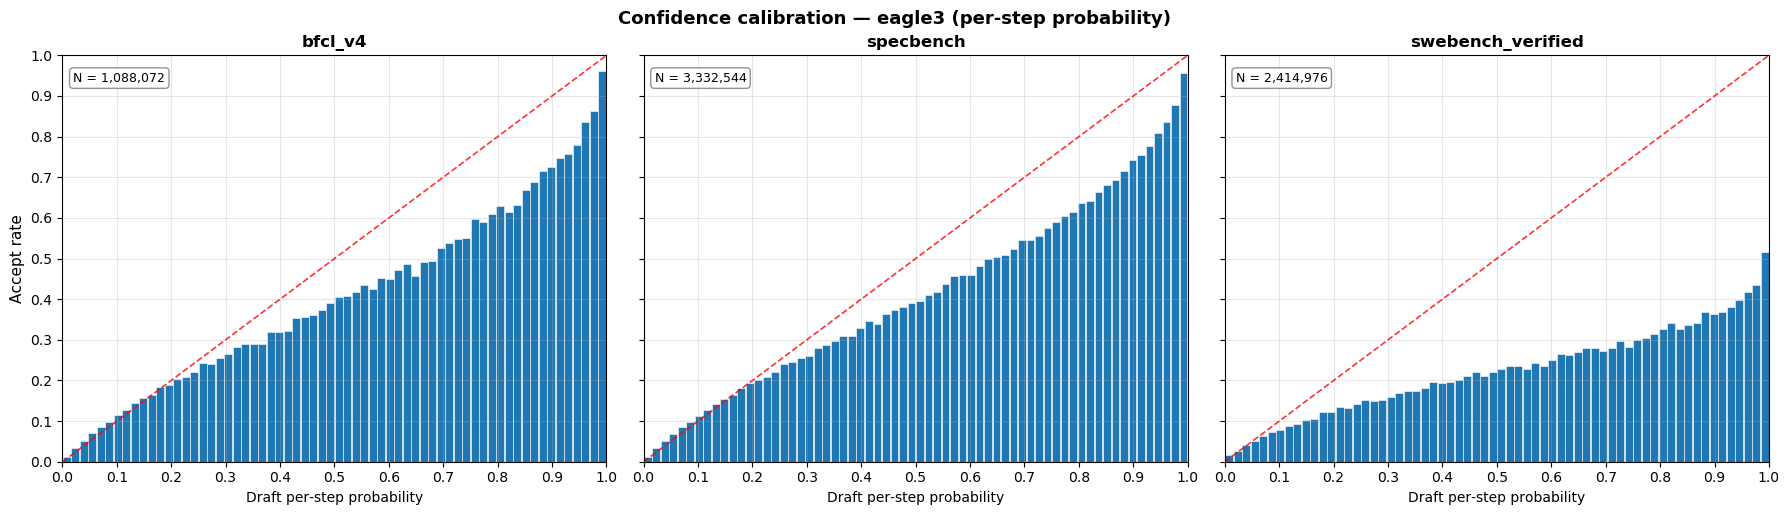

In [2]:
plot_calibration('eagle3', 'per_step', 'per-step probability')

## suffix

/tmp/ipykernel_2900178/1262282051.py:34: RuntimeWarning: invalid value encountered in divide
  rates = np.where(trials > 0, accepts / trials, np.nan)


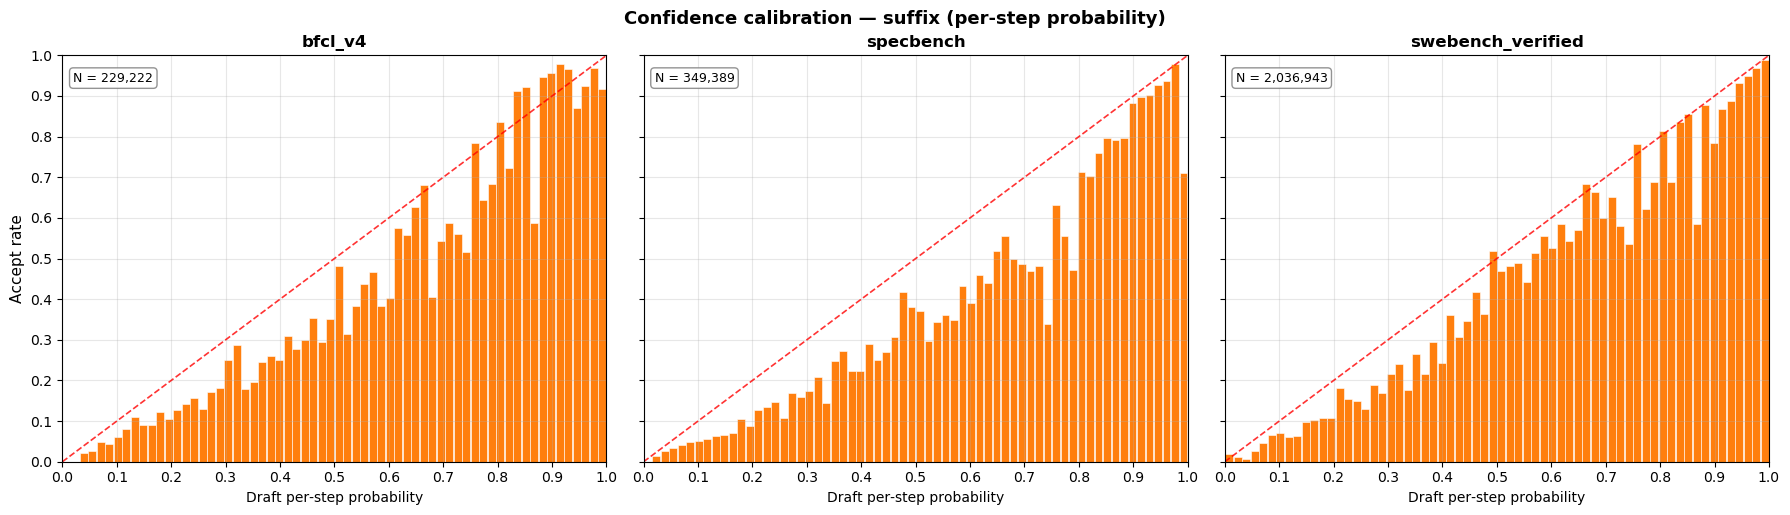

In [3]:
plot_calibration('suffix', 'per_step', 'per-step probability')

## draft_model

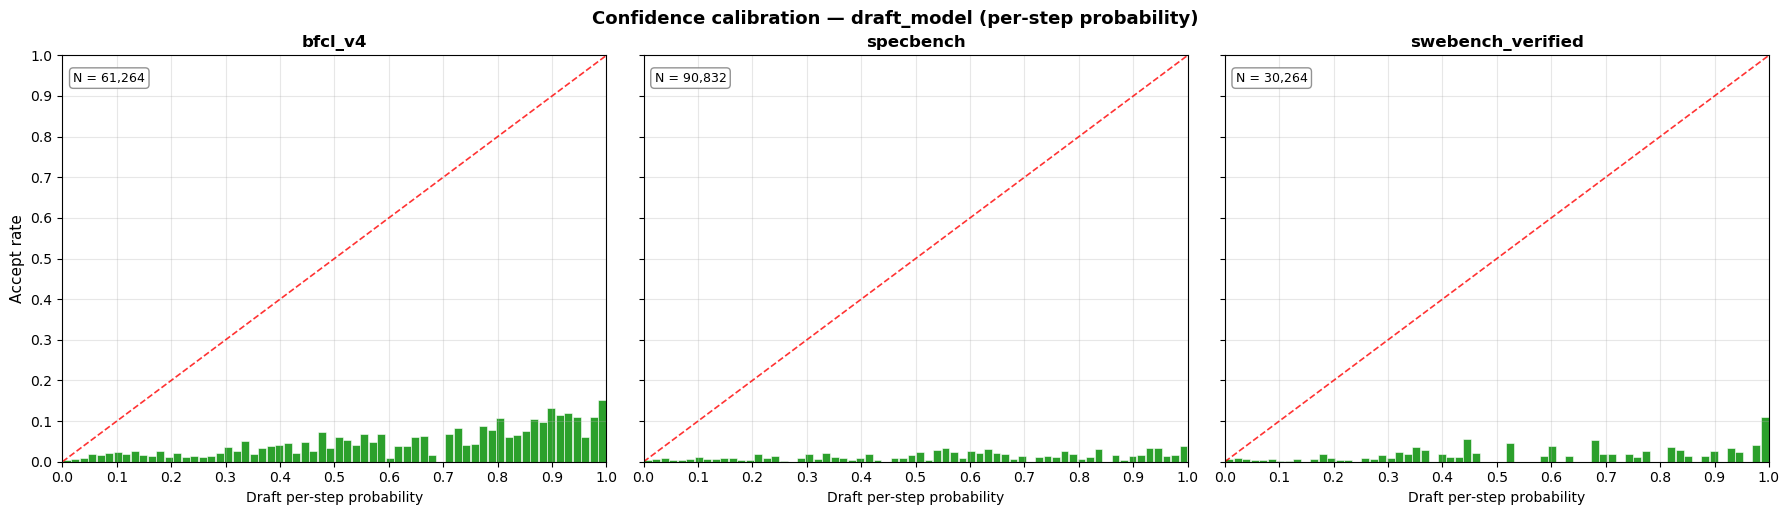

In [4]:
plot_calibration('draft_model', 'per_step', 'per-step probability')

## mtp

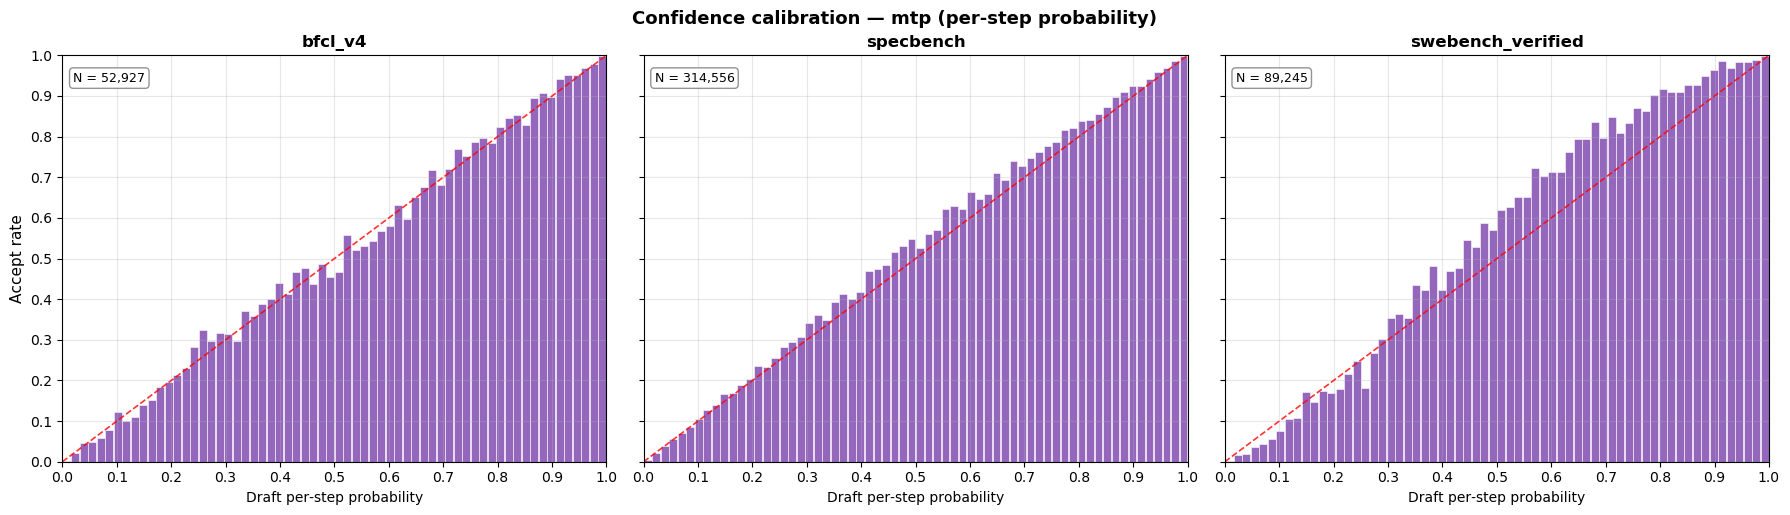

In [5]:
plot_calibration('mtp', 'per_step', 'per-step probability')

# Path-prob calibration (per-NODE cumulative path-product)

Per-NODE confidence = cumulative path-product `cum[i]` directly (= `path_draft_p_t[i]` for eagle3, `probs[i]` for suffix). Range [0, 1]. This is the absolute probability that the entire root→i path is correct — the metric tree pruning actually uses. Diagonal `y = x` is the perfect-calibration reference (both X and Y are probabilities).

## eagle3

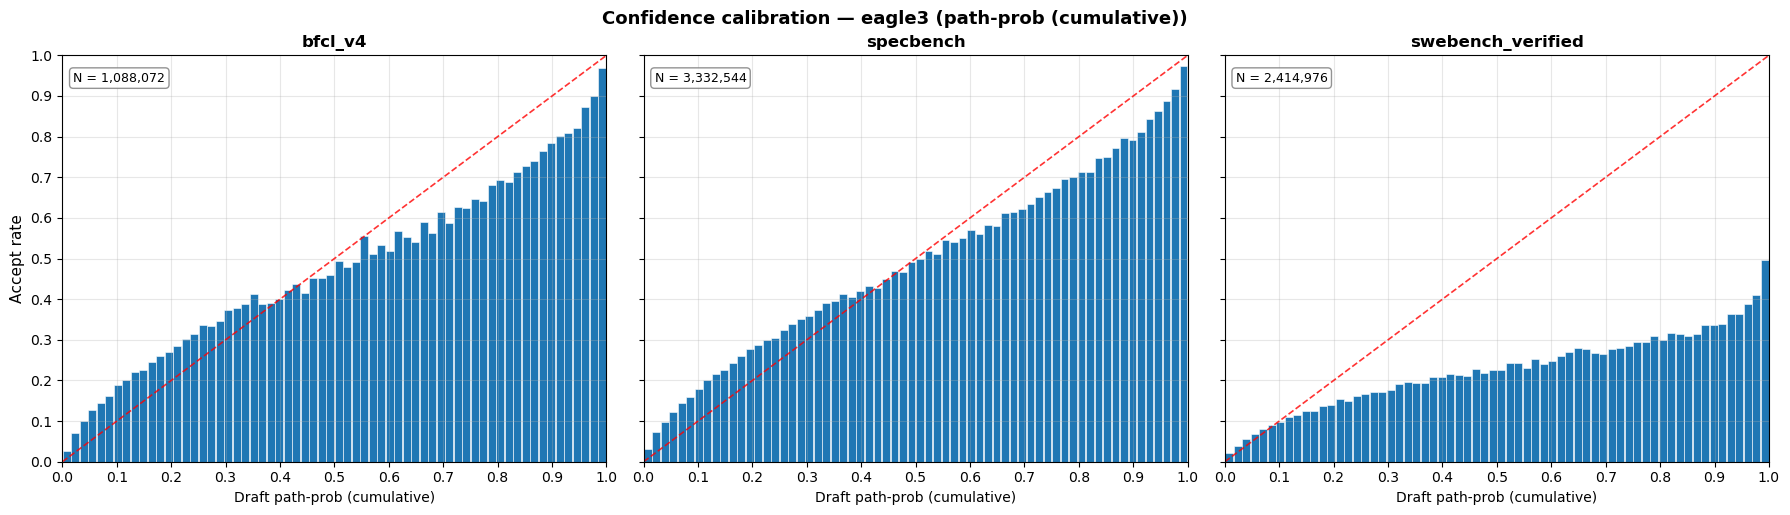

In [6]:
plot_calibration('eagle3', 'path_prob', 'path-prob (cumulative)')

## suffix

/tmp/ipykernel_2900178/1262282051.py:34: RuntimeWarning: invalid value encountered in divide
  rates = np.where(trials > 0, accepts / trials, np.nan)


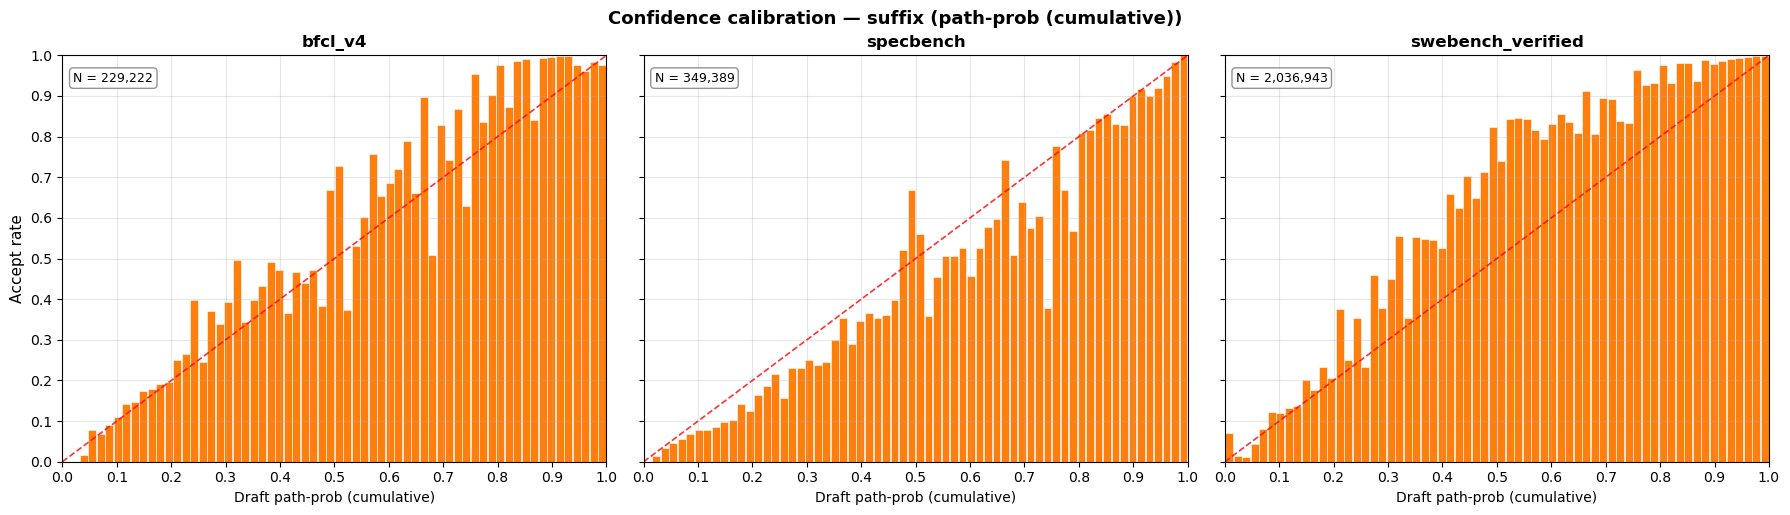

In [7]:
plot_calibration('suffix', 'path_prob', 'path-prob (cumulative)')

## draft_model

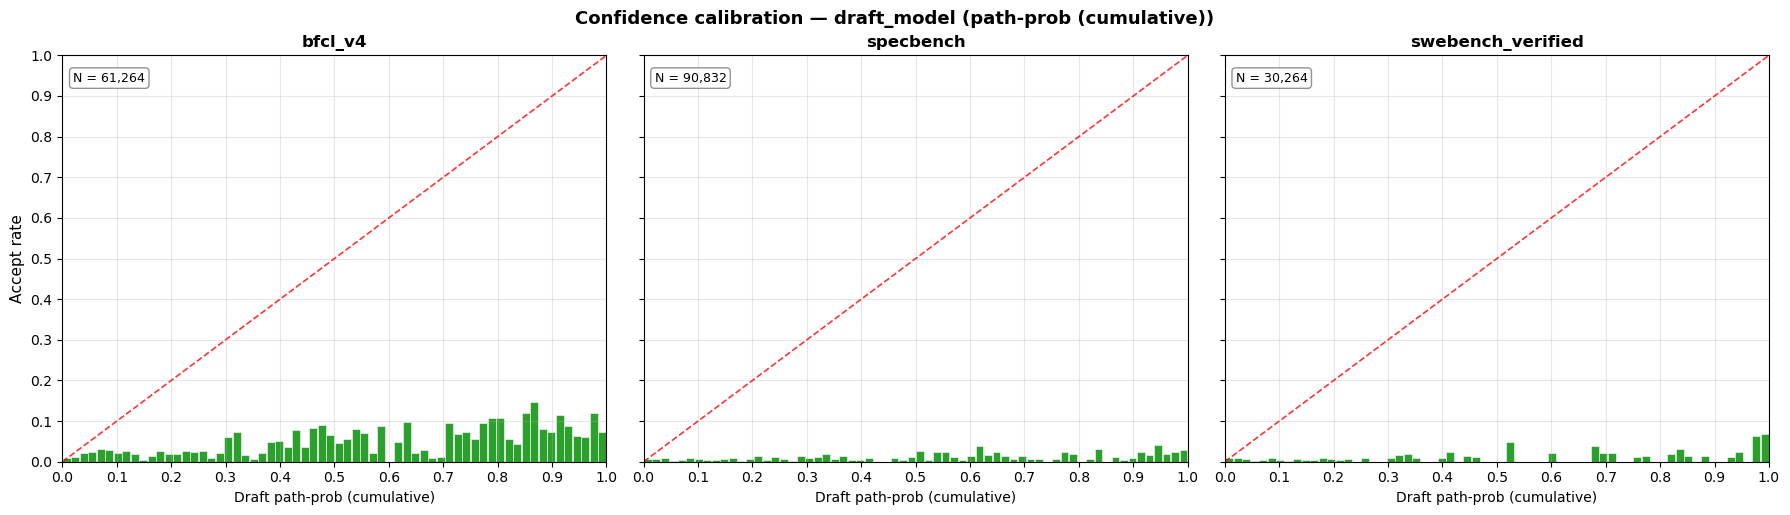

In [8]:
plot_calibration('draft_model', 'path_prob', 'path-prob (cumulative)')

## mtp

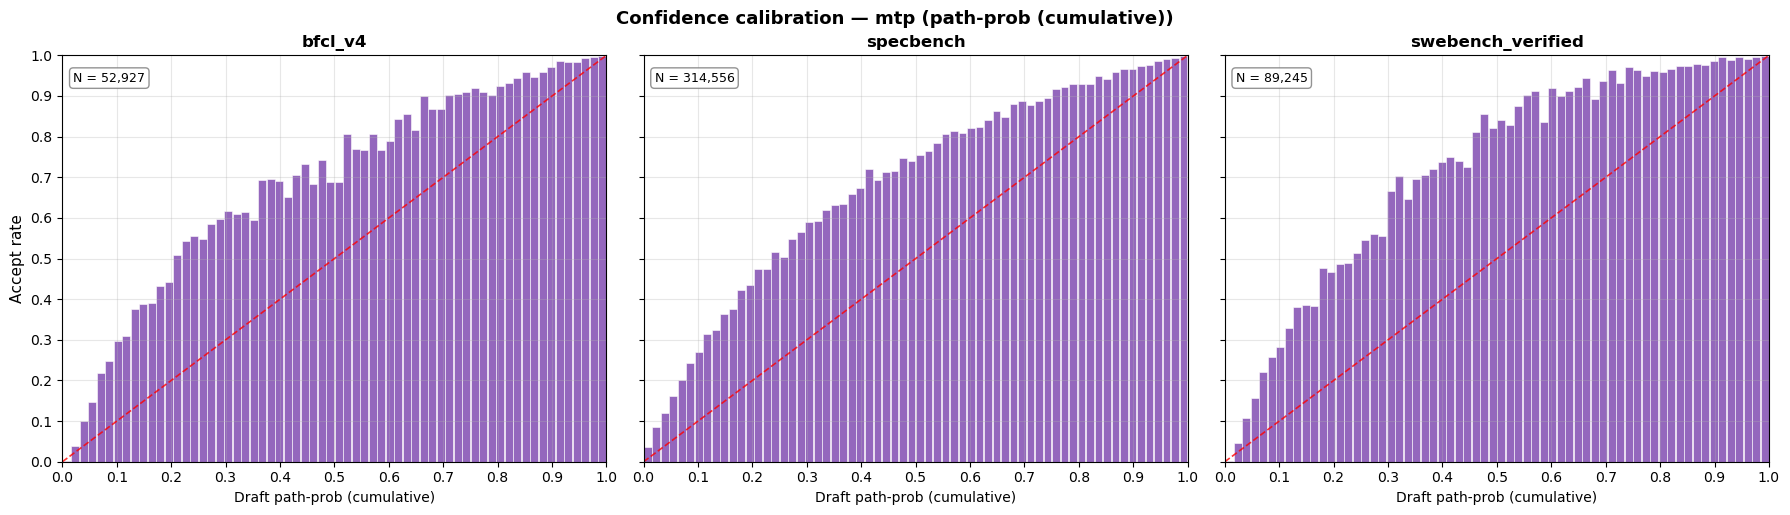

In [9]:
plot_calibration('mtp', 'path_prob', 'path-prob (cumulative)')

# Per-draft score calibration

Per-DRAFT scalar `SuffixDraft.score = sum(probs)` (suffix) / `sum(path_draft_p_t)` (eagle3), used **raw** (no normalization). X-axis spans `[0, score_max]` (default 8). Every trial node in one step uses its draft's score — so this measures "if a draft as a whole has higher total cumulative path-prob mass, are its individual nodes more likely to be accepted?"

Diagonal `y = x` is dropped because X (raw score) and Y (per-node accept rate) are no longer commensurate.

## eagle3

/tmp/ipykernel_2900178/1262282051.py:34: RuntimeWarning: invalid value encountered in divide
  rates = np.where(trials > 0, accepts / trials, np.nan)


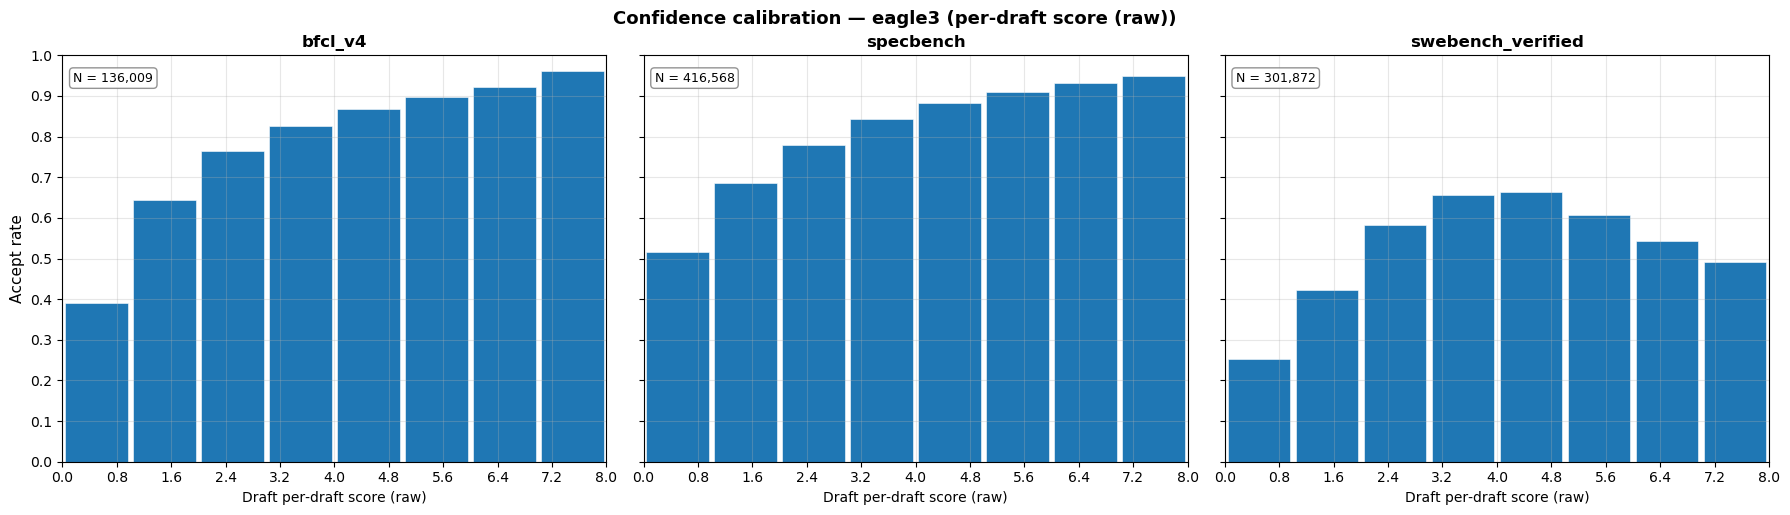

In [10]:
plot_calibration('eagle3', 'score', 'per-draft score (raw)')

## suffix

/tmp/ipykernel_2900178/1262282051.py:34: RuntimeWarning: invalid value encountered in divide
  rates = np.where(trials > 0, accepts / trials, np.nan)


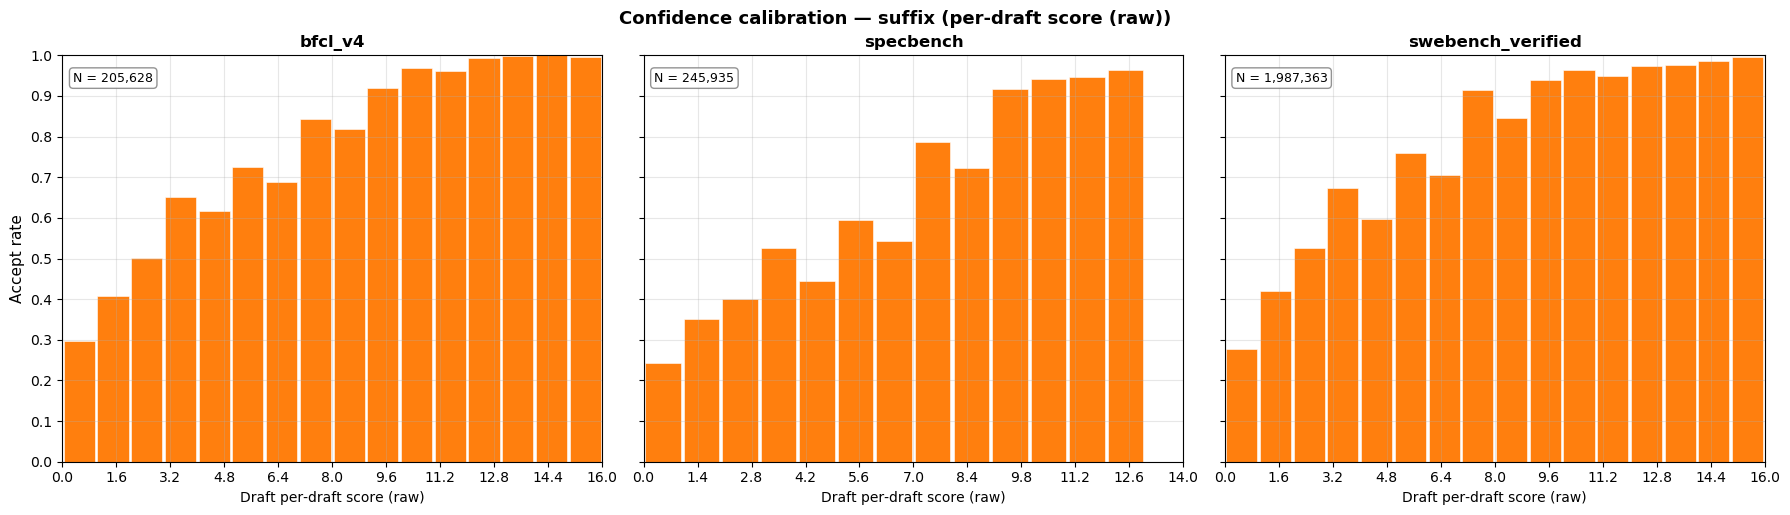

In [11]:
plot_calibration('suffix', 'score', 'per-draft score (raw)')

## draft_model

/tmp/ipykernel_2900178/1262282051.py:34: RuntimeWarning: invalid value encountered in divide
  rates = np.where(trials > 0, accepts / trials, np.nan)


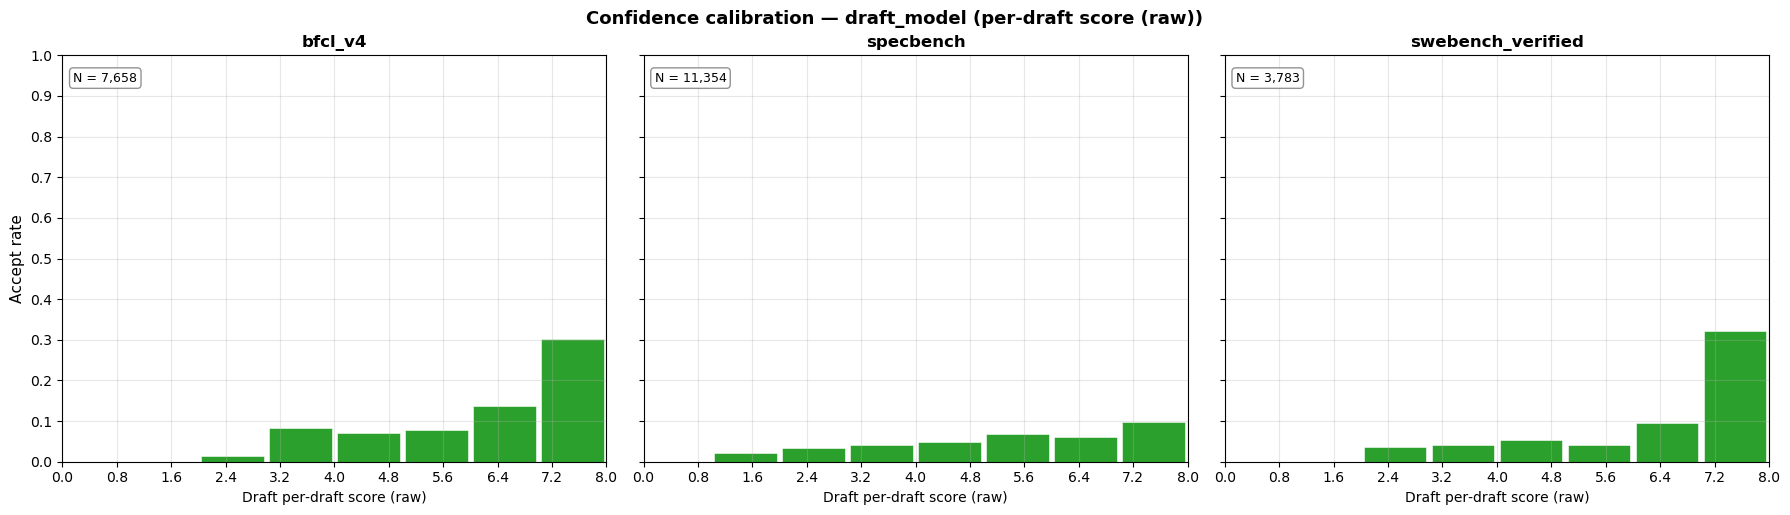

In [12]:
plot_calibration('draft_model', 'score', 'per-draft score (raw)')

## mtp

/tmp/ipykernel_2900178/1262282051.py:34: RuntimeWarning: invalid value encountered in divide
  rates = np.where(trials > 0, accepts / trials, np.nan)


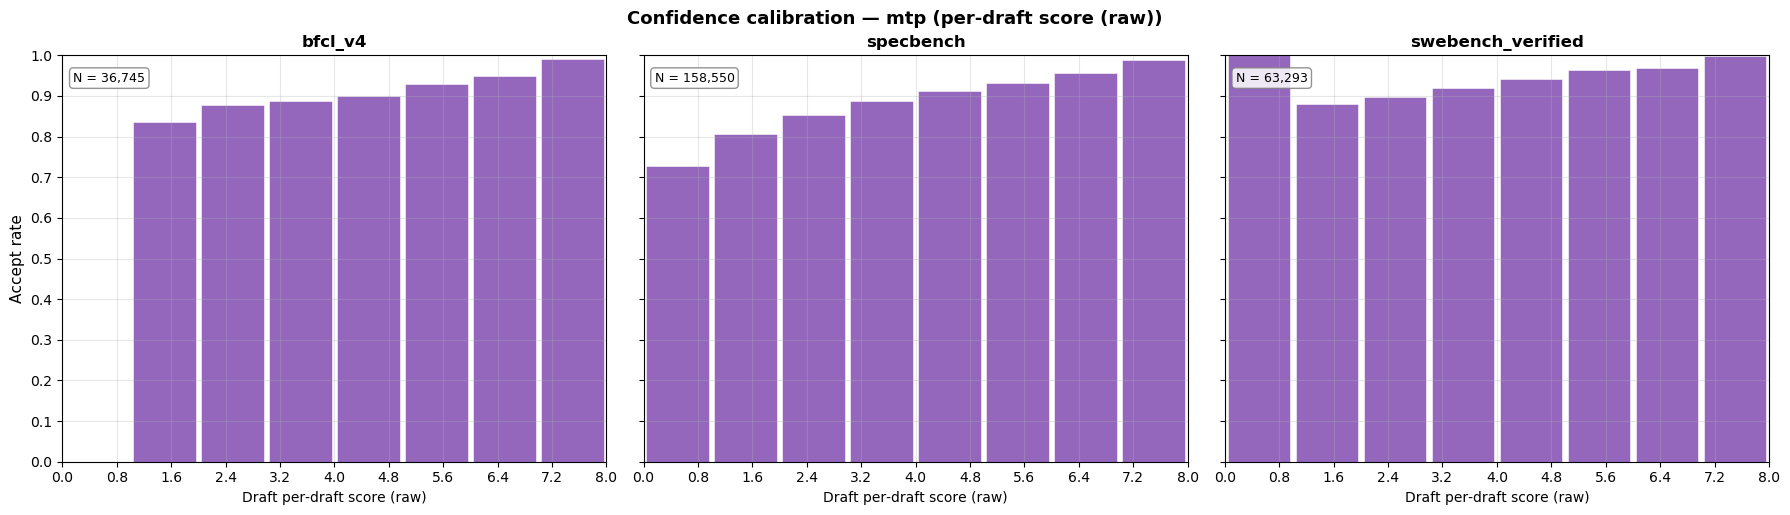

In [13]:
plot_calibration('mtp', 'score', 'per-draft score (raw)')

# Per-bin sample count (denominator)

Bins with very few trials give noisy rate estimates. Log-scale y so empty / sparse bins are visible.

## eagle3 — per-step

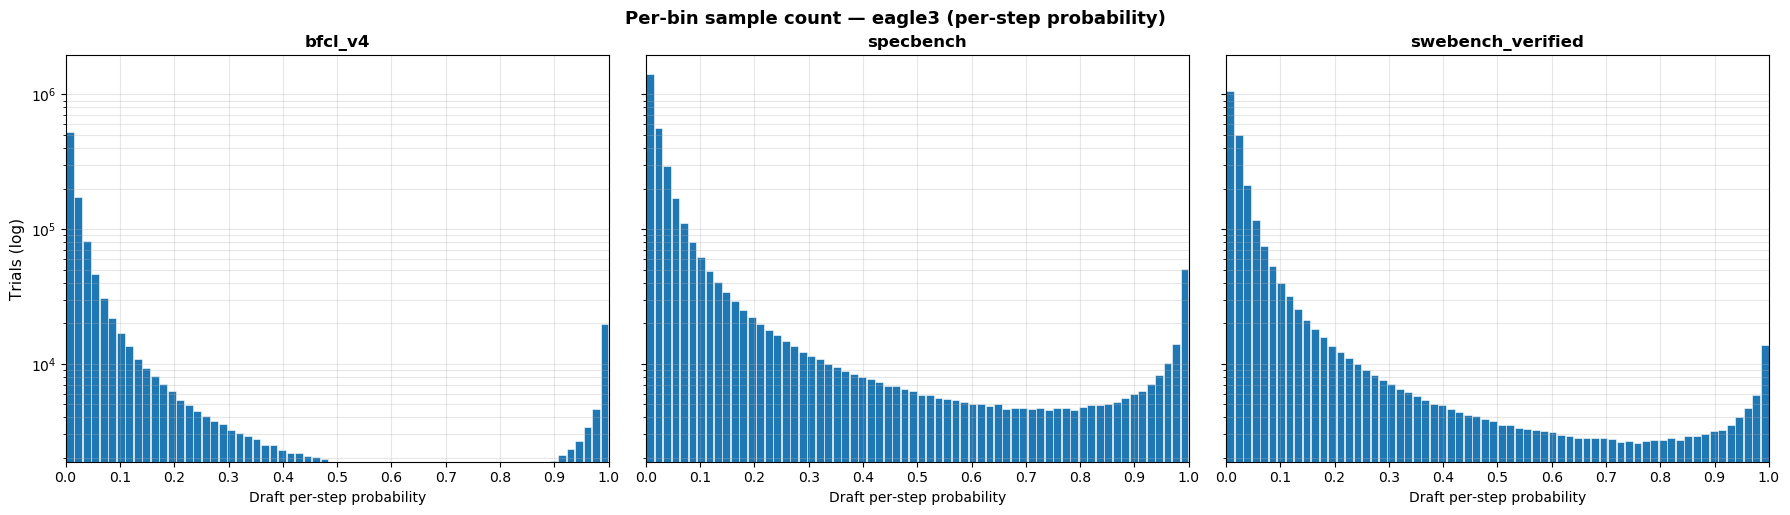

In [14]:
plot_sample_counts('eagle3', 'per_step', 'per-step probability')

## suffix — per-step

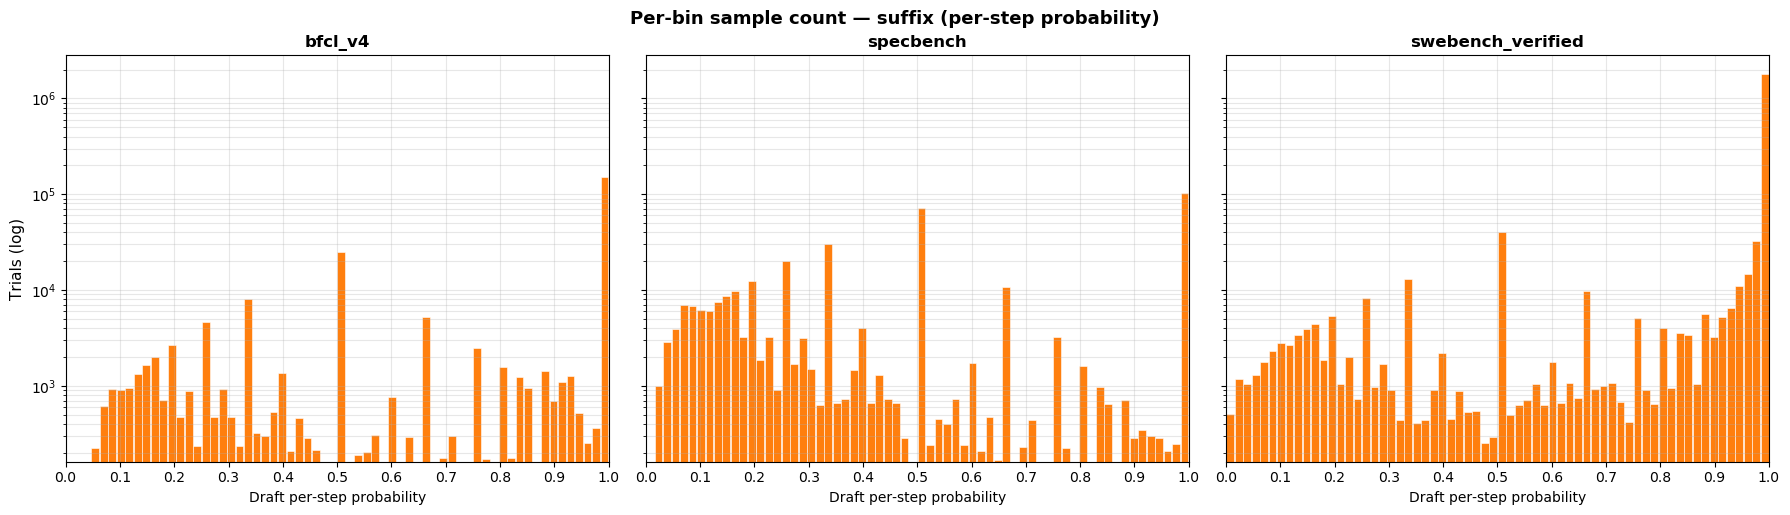

In [15]:
plot_sample_counts('suffix', 'per_step', 'per-step probability')

## draft_model — per-step

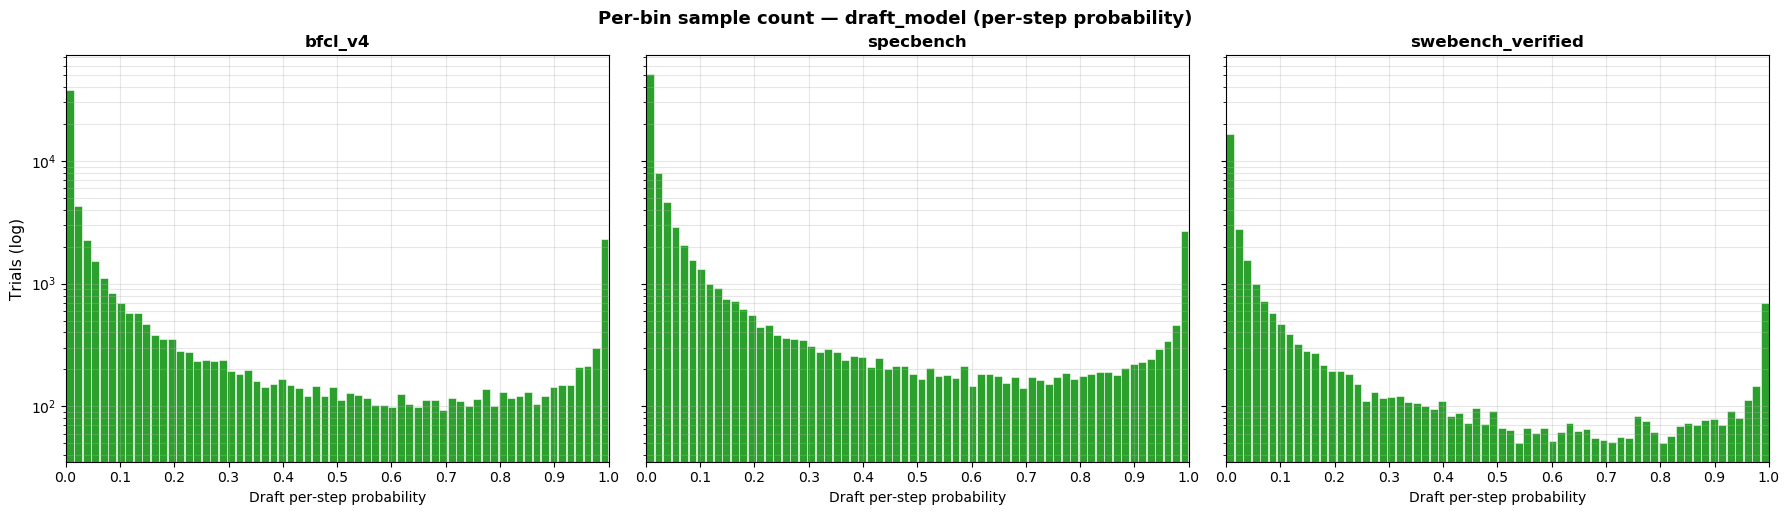

In [16]:
plot_sample_counts('draft_model', 'per_step', 'per-step probability')

## mtp — per-step

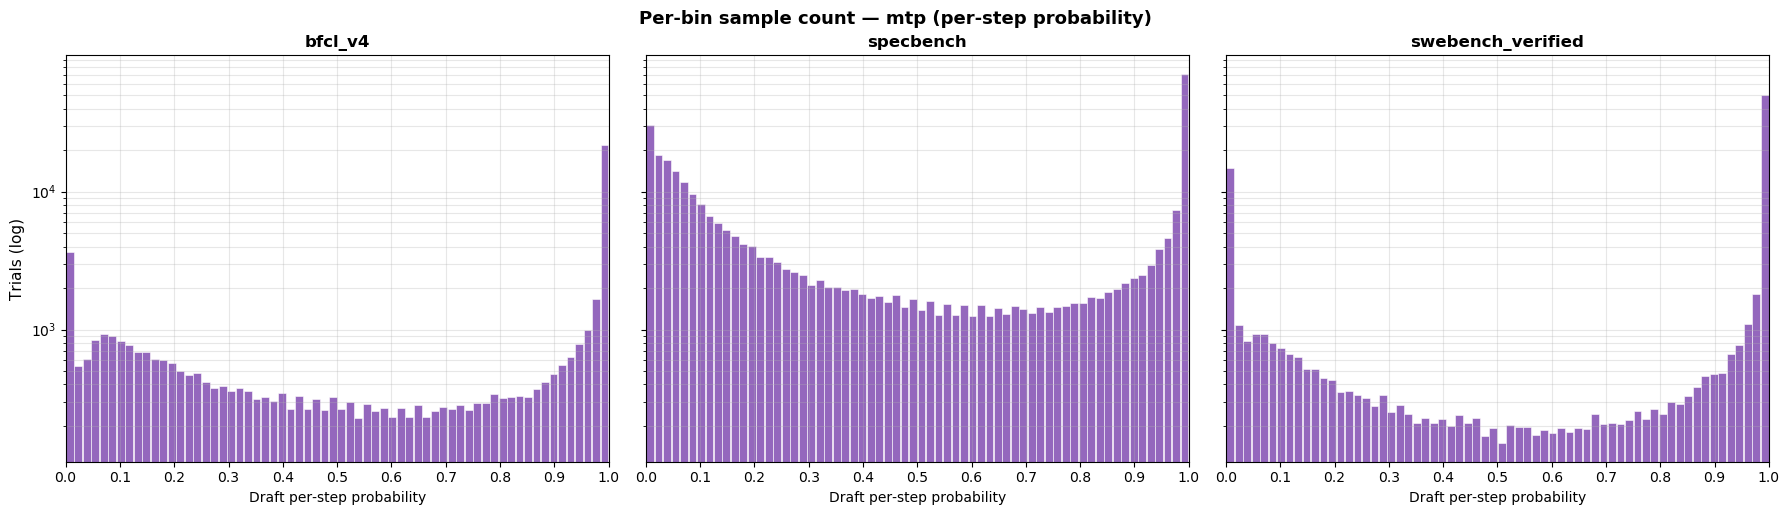

In [17]:
plot_sample_counts('mtp', 'per_step', 'per-step probability')

## eagle3 — path_prob

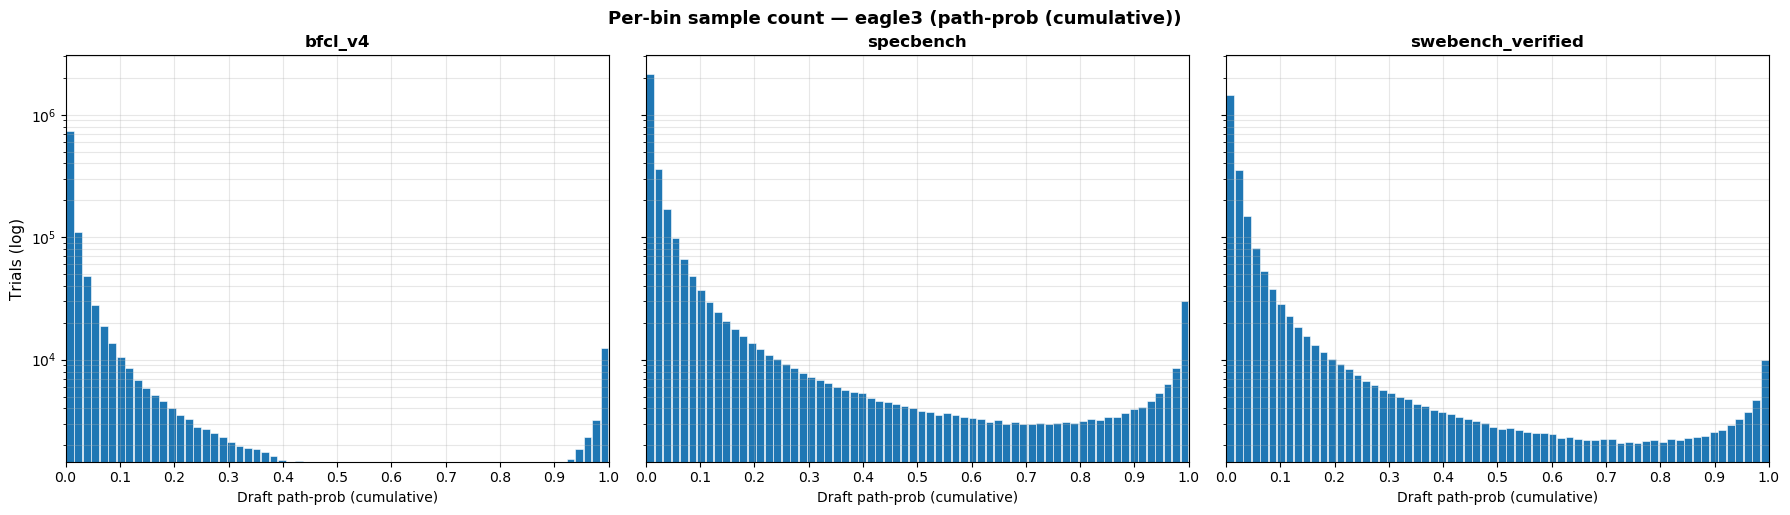

In [18]:
plot_sample_counts('eagle3', 'path_prob', 'path-prob (cumulative)')

## suffix — path_prob

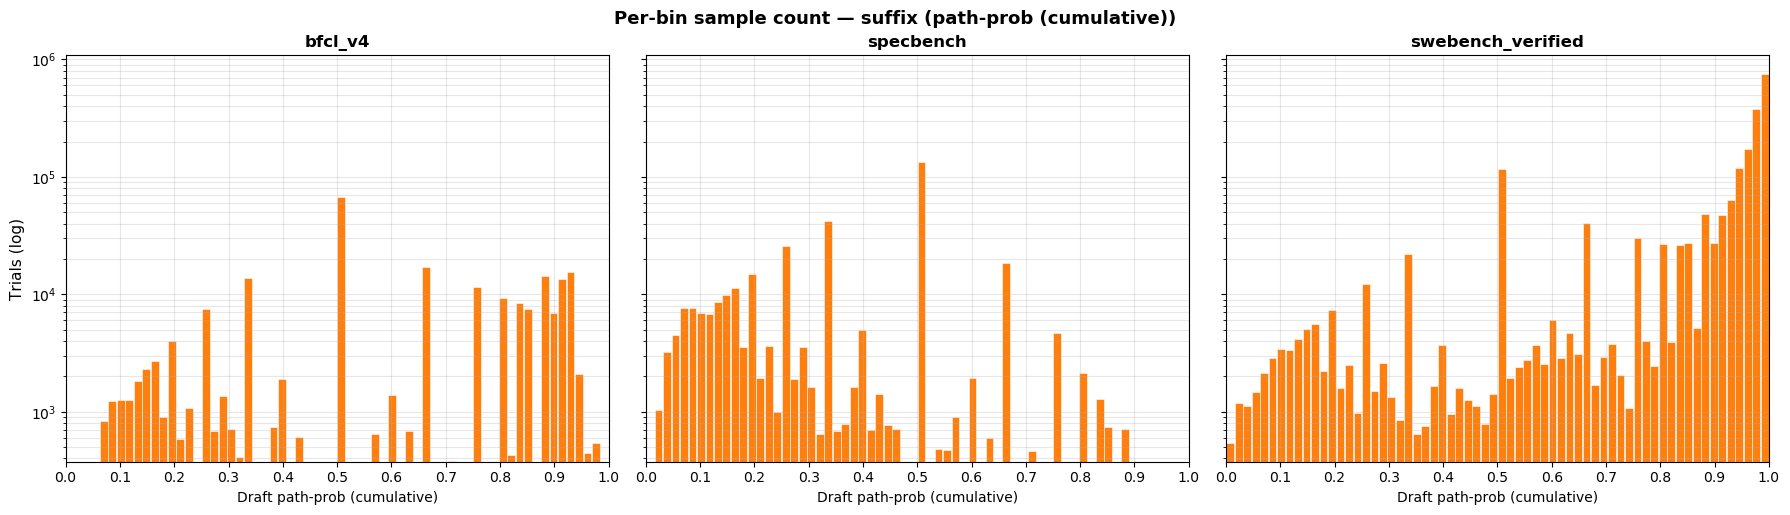

In [19]:
plot_sample_counts('suffix', 'path_prob', 'path-prob (cumulative)')

## draft_model — path_prob

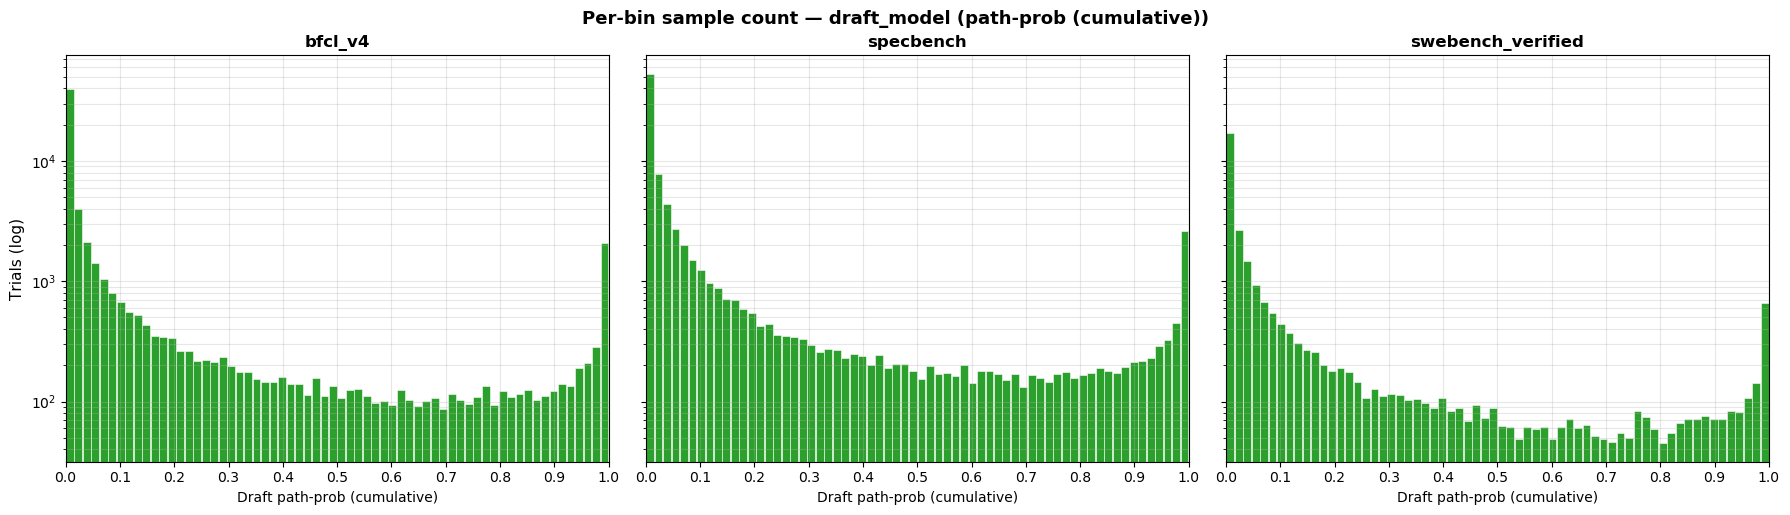

In [20]:
plot_sample_counts('draft_model', 'path_prob', 'path-prob (cumulative)')

## mtp — path_prob

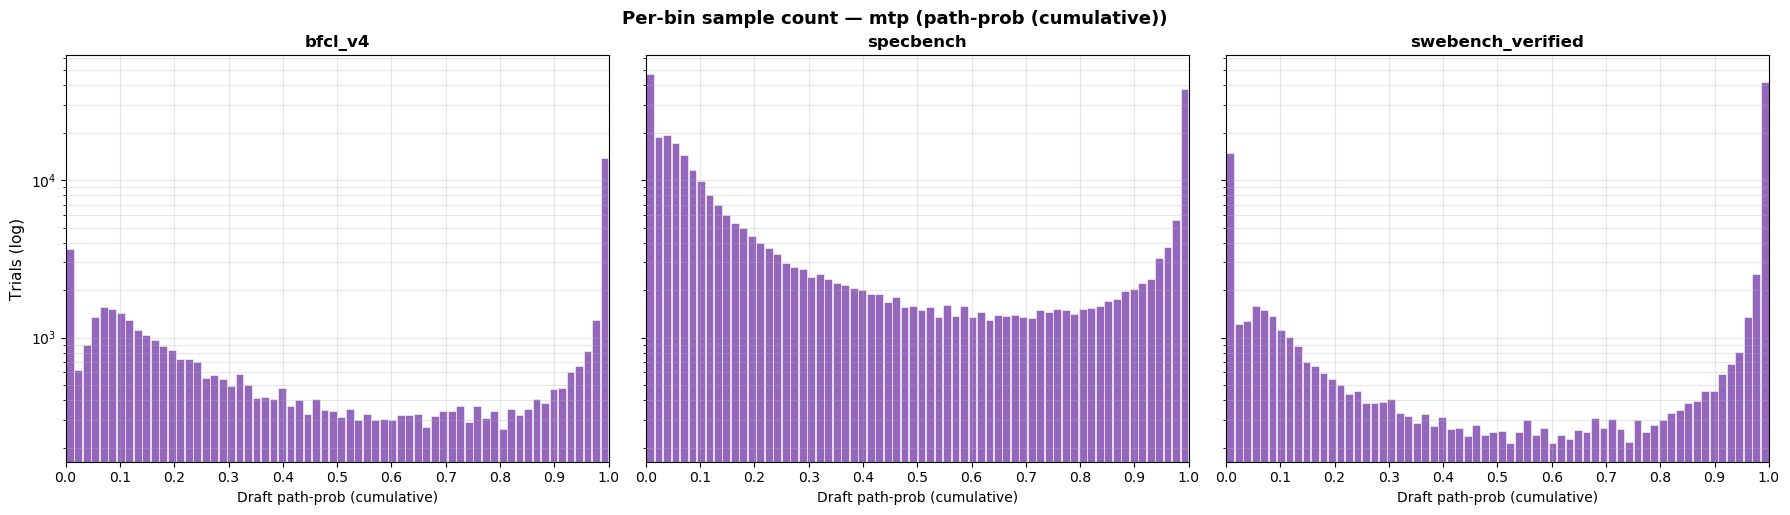

In [21]:
plot_sample_counts('mtp', 'path_prob', 'path-prob (cumulative)')

## eagle3 — score

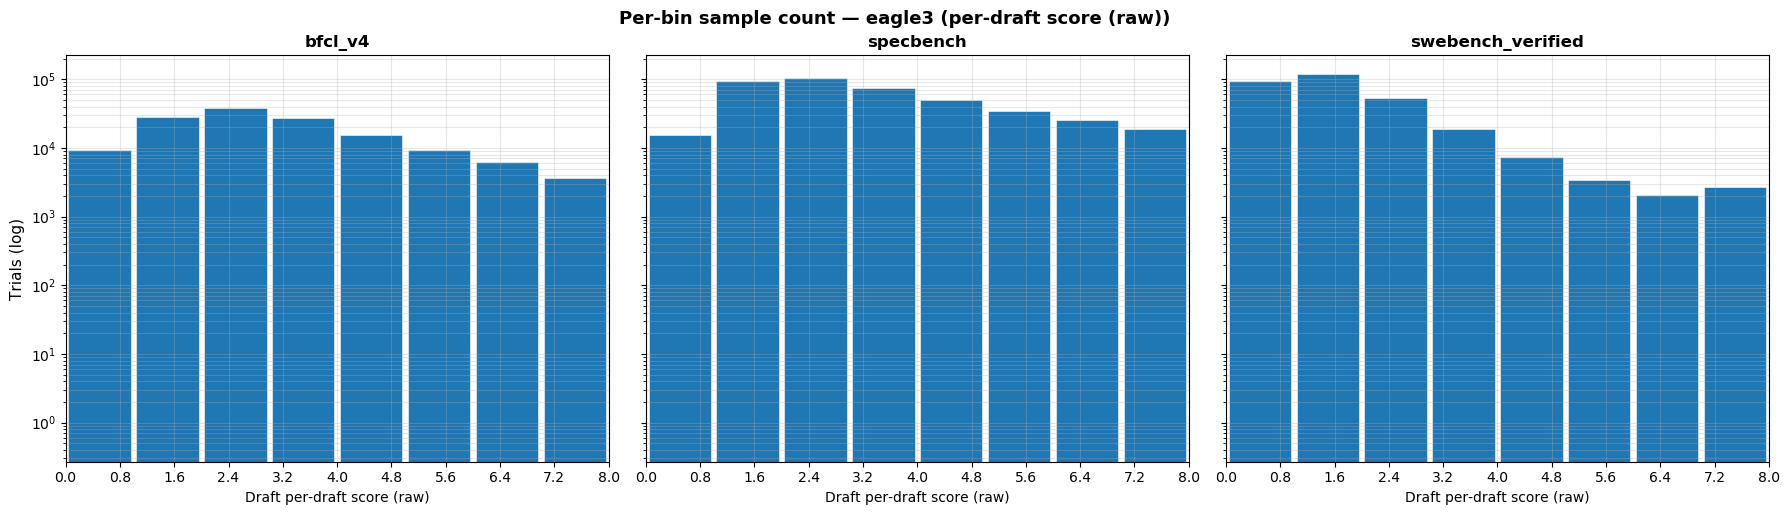

In [22]:
plot_sample_counts('eagle3', 'score', 'per-draft score (raw)')

## suffix — score

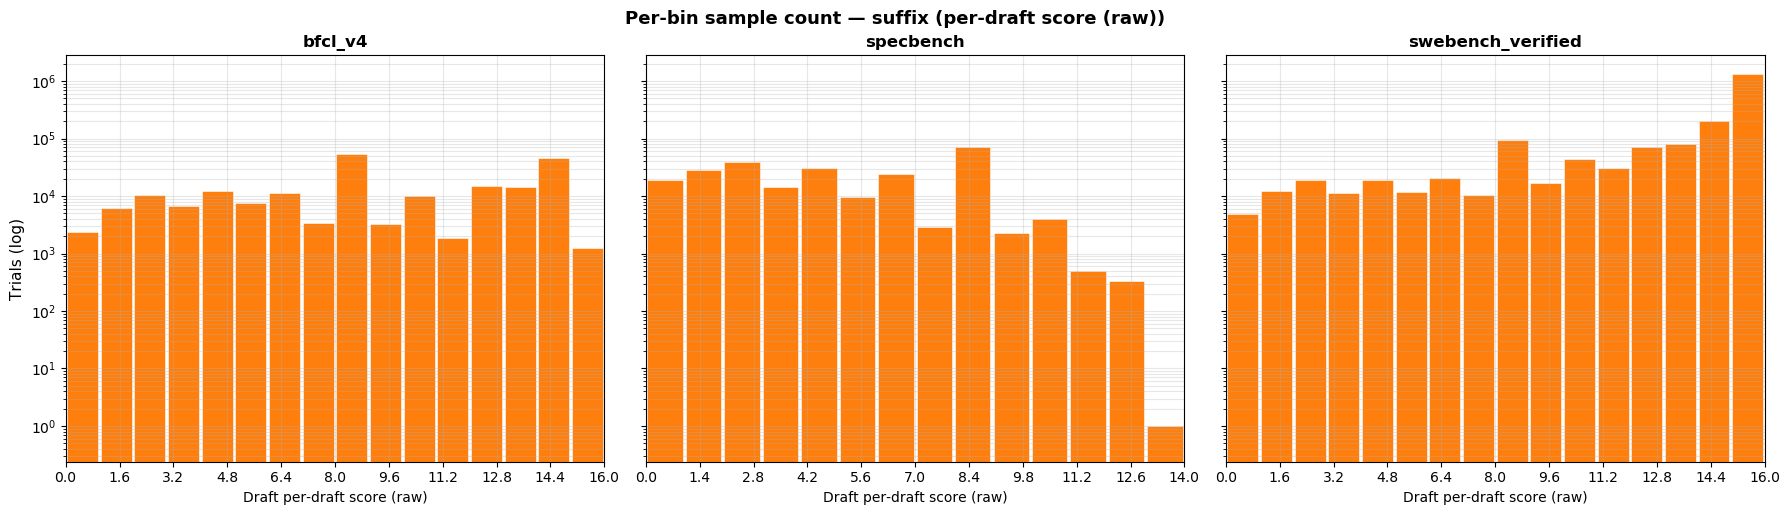

In [23]:
plot_sample_counts('suffix', 'score', 'per-draft score (raw)')

## draft_model — score

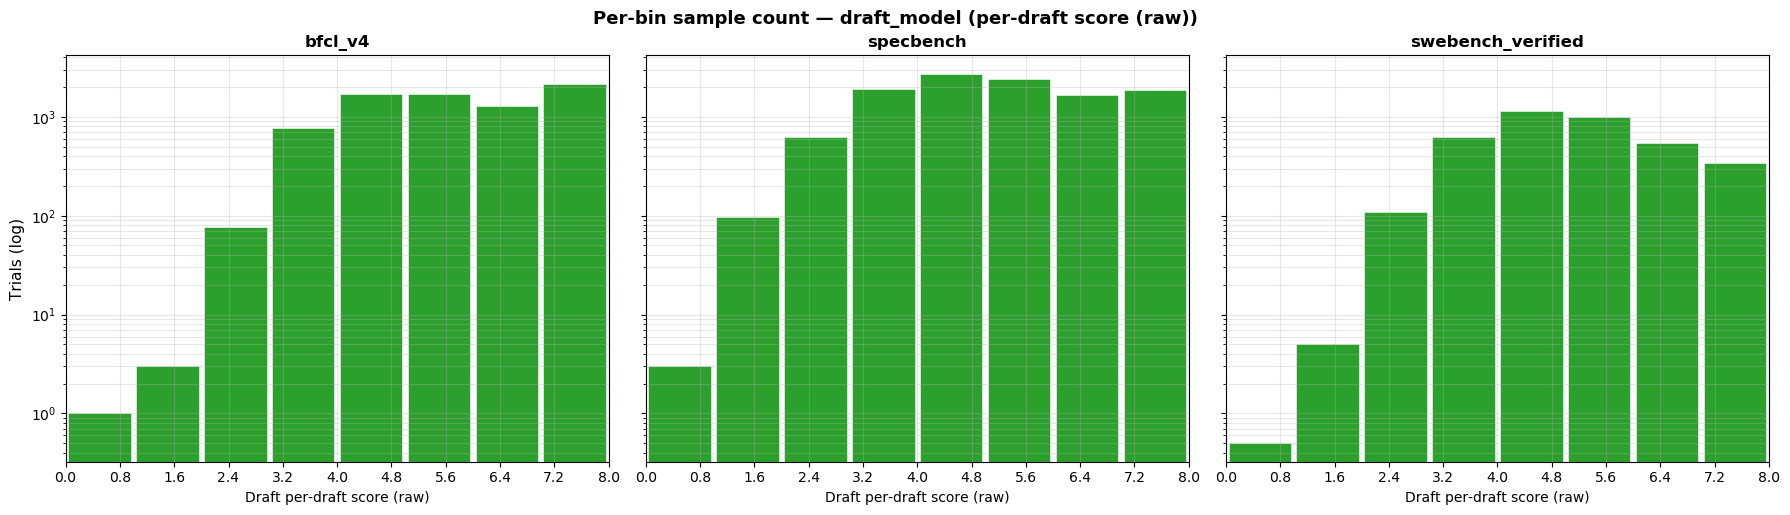

In [24]:
plot_sample_counts('draft_model', 'score', 'per-draft score (raw)')

## mtp — score

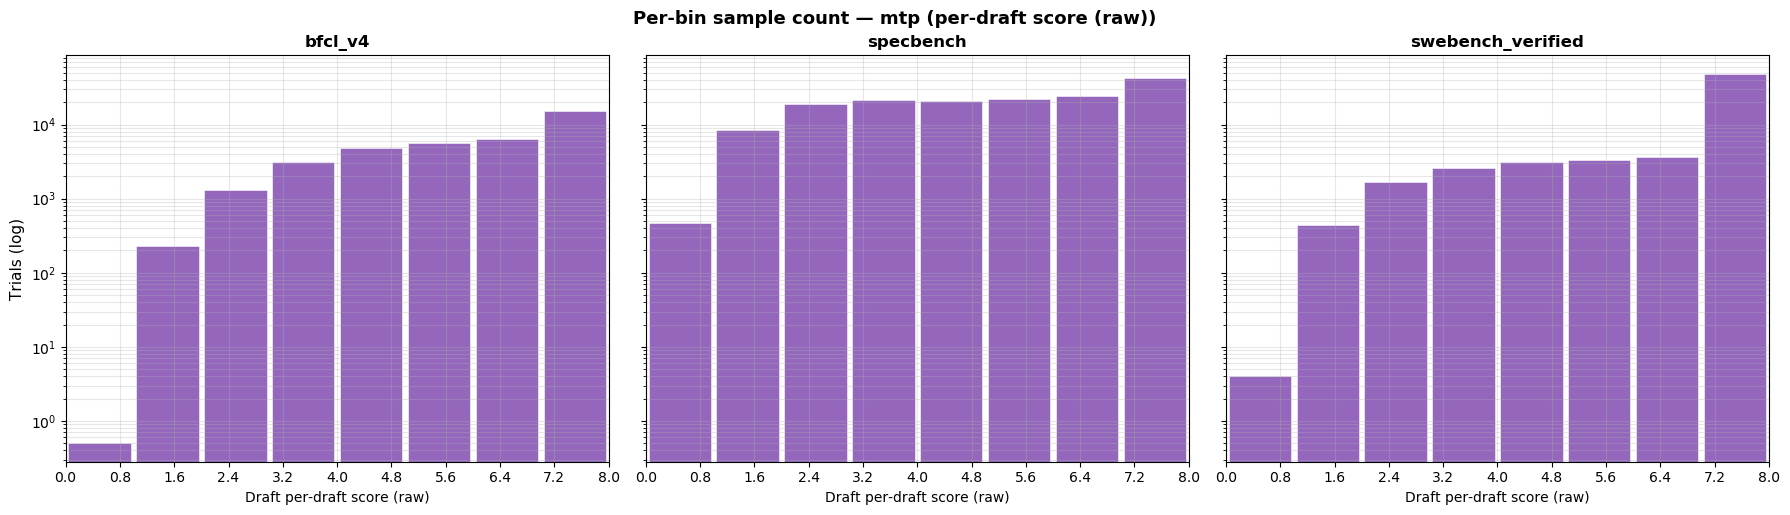

In [25]:
plot_sample_counts('mtp', 'score', 'per-draft score (raw)')

# Numerical table per workload (per-step probability axis)

Per-bin trials (denominator), accepts (numerator), and rate. NaN = empty bin.

In [26]:
METHODS_TBL = ('eagle3', 'suffix', 'draft_model', 'mtp')

for wl in WORKLOADS:
    c = calibs[wl]
    if c is None:
        print(f'\n=== {wl} === MISSING'); continue
    edges = c.get('per_step_bin_edges') or c.get('bin_edges')
    rows = []
    bm = c['by_method']
    for i in range(c['n_bins']):
        row = {'bin': f'[{edges[i]:.2f}, {edges[i+1]:.2f})'}
        for m in METHODS_TBL:
            ps = bm.get(m, {}).get('per_step')
            if ps is None:
                row[f'{m}_t'] = 0; row[f'{m}_a'] = 0; row[f'{m}_r'] = float('nan')
                continue
            t = ps['trials'][i]; a = ps['accepts'][i]
            row[f'{m}_t'] = t; row[f'{m}_a'] = a
            row[f'{m}_r'] = (a / t) if t else float('nan')
        rows.append(row)
    df = pd.DataFrame(rows)
    print(f'\n=== {wl} (per-step, all methods) ===')
    with pd.option_context('display.float_format', '{:.4f}'.format,
                            'display.max_rows', None,
                            'display.max_columns', None,
                            'display.width', 240):
        print(df.to_string(index=False))



=== bfcl_v4 (per-step, all methods) ===
         bin  eagle3_t  eagle3_a  eagle3_r  suffix_t  suffix_a  suffix_r  draft_model_t  draft_model_a  draft_model_r  mtp_t  mtp_a  mtp_r
[0.00, 0.02)    528218      5586    0.0106         0         0       NaN          37989            196         0.0052   3646      4 0.0011
[0.02, 0.03)    173173      5758    0.0332         0         0       NaN           4266             32         0.0075    541     11 0.0203
[0.03, 0.05)     81451      4118    0.0506        45         1    0.0222           2290             23         0.0100    609     28 0.0460
[0.05, 0.06)     46459      3278    0.0706       222         6    0.0270           1523             29         0.0190    843     40 0.0474
[0.06, 0.08)     30838      2669    0.0865       621        30    0.0483           1110             19         0.0171    925     54 0.0584
[0.08, 0.09)     22054      2139    0.0970       924        40    0.0433            832             17         0.0204    898 